# Notebook 03 - Exploratory Data Analysis (EDA)

Notebook này thực hiện phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA) trên bộ dữ liệu khảo sát sinh viên Việt Nam sau khi đã hoàn thành quá trình làm sạch và tiền xử lý ở Notebook 02.

Mục tiêu của notebook là cung cấp cái nhìn tổng quan về đặc điểm dữ liệu, phân bố của các biến nghiên cứu, mối quan hệ giữa các biến cũng như đặc điểm của Digital Burnout trong bộ dữ liệu khảo sát.

Các kết quả của notebook sẽ là cơ sở cho quá trình đánh giá đặc trưng (Feature Validation) ở Notebook 04.

# 0. Set Up

Thiết lập môi trường làm việc, import các thư viện cần thiết và cấu hình hiển thị phục vụ quá trình Exploratory Data Analysis.

In [36]:
# Import các thư viện phục vụ phân tích dữ liệu

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [37]:
# Thiết lập cấu hình hiển thị

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

sns.set_theme(style="whitegrid")

In [38]:
# Thiết lập đường dẫn dữ liệu

data_path = "../../data/processed/vietnam_dataset/vn_digital_burnout_cleaned.csv"

print("Đã thiết lập đường dẫn dữ liệu.")

Đã thiết lập đường dẫn dữ liệu.


# 1. Load Dataset

Đọc bộ dữ liệu đã được làm sạch từ Notebook 02 và kiểm tra thông tin tổng quan trước khi thực hiện Exploratory Data Analysis.

In [39]:
# Đọc bộ dữ liệu đã làm sạch

cleaned_dataset = pd.read_csv(data_path)

print("Đã tải bộ dữ liệu thành công.")

Đã tải bộ dữ liệu thành công.


In [40]:
# Hiển thị kích thước bộ dữ liệu

print(f"Số lượng bản ghi: {cleaned_dataset.shape[0]}")
print(f"Số lượng thuộc tính: {cleaned_dataset.shape[1]}")

Số lượng bản ghi: 590
Số lượng thuộc tính: 23


In [41]:
# Hiển thị thông tin tổng quan

cleaned_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   gender                   590 non-null    object
 1   birth_year               590 non-null    object
 2   education_stage          590 non-null    object
 3   work_mode                590 non-null    object
 4   device_usage_type        590 non-null    object
 5   daily_screen_time        590 non-null    int64 
 6   social_media_hours       590 non-null    int64 
 7   doomscrolling_duration   590 non-null    int64 
 8   late_night_device_usage  590 non-null    int64 
 9   notification_count       590 non-null    int64 
 10  smartphone_unlocks       590 non-null    int64 
 11  app_switch_frequency     590 non-null    int64 
 12  concentration_score      590 non-null    int64 
 13  distraction_frequency    590 non-null    int64 
 14  focus_sessions           590 non-null    i

In [42]:
# Khai báo các nhóm biến nghiên cứu

demographic_features = [
    "gender",
    "birth_year",
    "education_stage"
]

learning_context_features = [
    "work_mode"
]

digital_exposure_features = [
    "device_usage_type",
    "daily_screen_time",
    "social_media_hours",
    "doomscrolling_duration",
    "late_night_device_usage",
    "notification_count",
    "smartphone_unlocks",
    "app_switch_frequency"
]

cognitive_performance_features = [
    "concentration_score",
    "distraction_frequency",
    "focus_sessions",
    "deep_work_hours",
    "task_completion_rate"
]

sleep_recovery_features = [
    "sleep_hours",
    "sleep_quality"
]

burnout_symptom_features = [
    "emotional_exhaustion",
    "stress_level",
    "mental_fatigue"
]

In [43]:
# Tổng hợp thông tin các nhóm biến nghiên cứu

feature_group_summary = pd.DataFrame(
    {
        "feature_group": [
            "Demographic Information",
            "Learning Context",
            "Digital Exposure",
            "Cognitive Performance",
            "Sleep & Recovery",
            "Burnout Symptoms"
        ],
        "number_of_features": [
            len(demographic_features),
            len(learning_context_features),
            len(digital_exposure_features),
            len(cognitive_performance_features),
            len(sleep_recovery_features),
            len(burnout_symptom_features)
        ]
    }
)

feature_group_summary

,feature_group,number_of_features
0,Demographic Information,3
1,Learning Context,1
2,Digital Exposure,8
3,Cognitive Performance,5
4,Sleep & Recovery,2
5,Burnout Symptoms,3


In [44]:
# Hiển thị các nhóm biến nghiên cứu

feature_groups = {
    "Demographic Information": demographic_features,
    "Learning Context": learning_context_features,
    "Digital Exposure": digital_exposure_features,
    "Cognitive Performance": cognitive_performance_features,
    "Sleep & Recovery": sleep_recovery_features,
    "Burnout Symptoms": burnout_symptom_features
}

for group_name, features in feature_groups.items():
    print(f"\n{group_name}")
    print("-" * len(group_name))
    print(", ".join(features))


Demographic Information
-----------------------
gender, birth_year, education_stage

Learning Context
----------------
work_mode

Digital Exposure
----------------
device_usage_type, daily_screen_time, social_media_hours, doomscrolling_duration, late_night_device_usage, notification_count, smartphone_unlocks, app_switch_frequency

Cognitive Performance
---------------------
concentration_score, distraction_frequency, focus_sessions, deep_work_hours, task_completion_rate

Sleep & Recovery
----------------
sleep_hours, sleep_quality

Burnout Symptoms
----------------
emotional_exhaustion, stress_level, mental_fatigue


In [53]:
feature_labels = {
    "gender" : "Gender",
    "birth_year": "Birth Year",
    "education_stage": "Education Stage",
    "device_usage_type": "Device Usage Type",
    "daily_screen_time": "Daily Screen Time",
    "social_media_hours": "Social Media Hours",
    "doomscrolling_duration": "Doomscrolling Duration",
    "late_night_device_usage": "Late-night Device Usage",
    "notification_count": "Notification Count",
    "smartphone_unlocks": "Smartphone Unlocks",
    "app_switch_frequency": "App Switch Frequency",
    "work_mode": "Work Mode",
    "concentration_score": "Concentration Score",
    "distraction_frequency": "Distraction Frequency",
    "focus_sessions": "Focus Sessions",
    "deep_work_hours": "Deep Work Hours",
    "task_completion_rate": "Task Completion Rate",
    "sleep_hours": "Sleep Hours",
    "sleep_quality": "Sleep Quality",
    "emotional_exhaustion": "Emotional Exhaustion",
    "stress_level": "Stress Level",
    "mental_fatigue": "Mental Fatigue"
}

# 2. Descriptive Statistics

Thực hiện thống kê mô tả nhằm cung cấp cái nhìn tổng quan về đặc điểm của bộ dữ liệu khảo sát sinh viên Việt Nam. Kết quả thống kê giúp nhận diện phân bố của các biến nghiên cứu trước khi tiến hành các phân tích chuyên sâu ở các phần tiếp theo.

## 2.1 Descriptive Statistics for Numerical Variables

Thống kê các chỉ số mô tả của các biến định lượng nhằm đánh giá đặc điểm phân bố và phạm vi giá trị của dữ liệu.

In [46]:
# Lựa chọn các biến định lượng

numeric_columns = cleaned_dataset.select_dtypes(
    include=["int64", "float64"]
).columns

print(f"Số lượng biến định lượng: {len(numeric_columns)}")

Số lượng biến định lượng: 18


In [47]:
# Thống kê mô tả các biến định lượng

numeric_summary = (
    cleaned_dataset[numeric_columns]
    .describe()
    .T
    .round(2)
)

numeric_summary

,count,mean,std,min,25%,50%,75%,max
daily_screen_time,590.0,2.87,1.07,0.0,2.00,3.0,4.0,4.0
social_media_hours,590.0,1.98,0.83,0.0,1.00,2.0,3.0,3.0
doomscrolling_duration,590.0,2.60,1.22,0.0,2.00,3.0,4.0,4.0
late_night_device_usage,590.0,2.81,0.56,0.0,3.00,3.0,3.0,3.0
notification_count,590.0,1.19,1.01,0.0,0.00,1.0,2.0,3.0
smartphone_unlocks,590.0,1.50,0.85,0.0,1.00,1.0,2.0,3.0
app_switch_frequency,590.0,1.27,1.02,0.0,1.00,1.0,2.0,3.0
concentration_score,590.0,5.47,2.12,1.0,4.00,6.0,7.0,10.0
distraction_frequency,590.0,1.76,0.90,0.0,1.00,2.0,2.0,3.0
focus_sessions,590.0,1.95,0.80,0.0,1.00,2.0,3.0,3.0


## 2.2 Descriptive Statistics for Categorical Variables

Thống kê các biến phân loại nhằm xác định số lượng nhóm giá trị và tần suất xuất hiện của từng biến.

In [48]:
# Lựa chọn các biến phân loại

categorical_columns = cleaned_dataset.select_dtypes(
    include="object"
).columns

print(f"Số lượng biến phân loại: {len(categorical_columns)}")

Số lượng biến phân loại: 5


In [49]:
# Thống kê mô tả các biến phân loại

categorical_summary = (
    cleaned_dataset[categorical_columns]
    .describe()
    .T
)

categorical_summary

,count,unique,top,freq
gender,590,2,Nữ,381
birth_year,590,5,2003 - 2005,217
education_stage,590,7,Sinh viên đại học / cao đẳng (năm 3-4+),225
work_mode,590,4,Hoàn toàn trực tiếp (đến trường / văn phòng ≥ ...,441
device_usage_type,590,4,Cân bằng cả học lẫn giải trí,437


# 3. Feature Distribution Analysis

Phân tích phân bố của các nhóm biến nghiên cứu trong bộ dữ liệu khảo sát sinh viên Việt Nam nhằm nhận diện đặc điểm dữ liệu, xu hướng phân bố và sự khác biệt giữa các nhóm biến trước khi thực hiện các phân tích mối quan hệ ở các phần tiếp theo.


## 3.1 Demographic Information

Khảo sát phân bố các đặc điểm nhân khẩu học của người tham gia khảo sát.

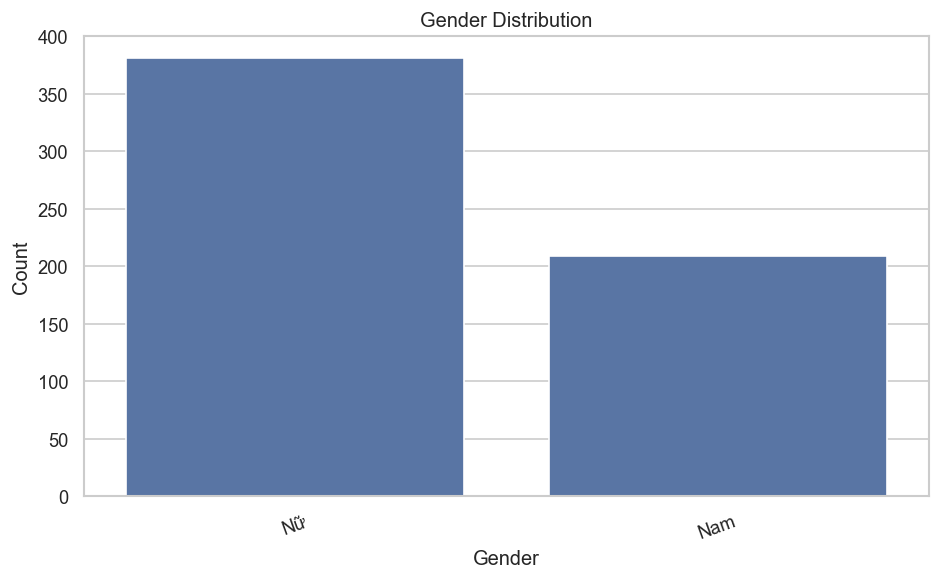

,count
gender,
Nữ,381
Nam,209


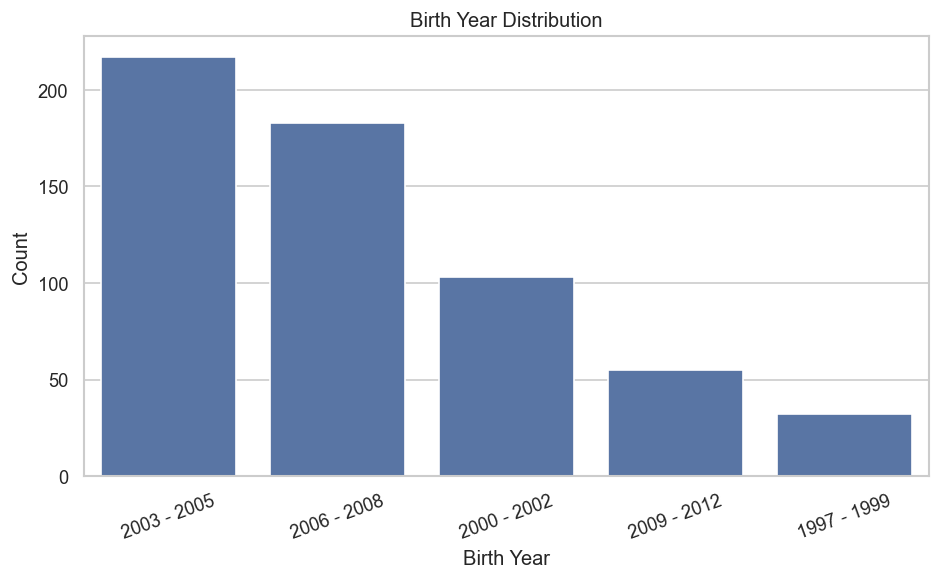

,count
birth_year,
2003 - 2005,217
2006 - 2008,183
2000 - 2002,103
2009 - 2012,55
1997 - 1999,32


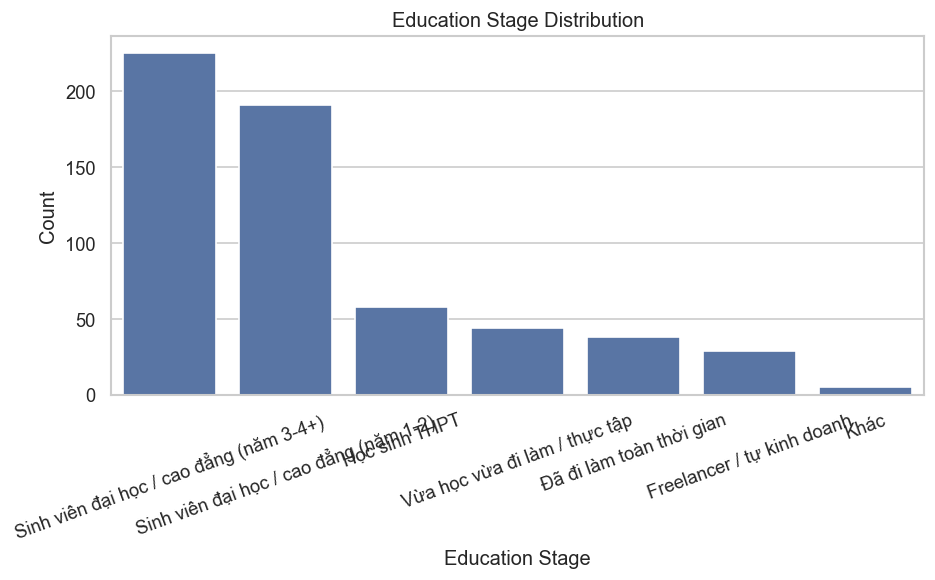

,count
education_stage,
Sinh viên đại học / cao đẳng (năm 3-4+),225
Sinh viên đại học / cao đẳng (năm 1-2),191
Học sinh THPT,58
Vừa học vừa đi làm / thực tập,44
Đã đi làm toàn thời gian,38
Freelancer / tự kinh doanh,29
Khác,5


In [54]:
# Hiển thị phân bố các biến nhân khẩu học

for column in demographic_features:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=cleaned_dataset,
        x=column,
        order=cleaned_dataset[column].value_counts().index
    )

    plt.title(f"{feature_labels[column]} Distribution")
    plt.xlabel(feature_labels[column])
    plt.ylabel("Count")

    plt.xticks(rotation=20)

    plt.tight_layout()

    plt.show()

    print("\n")

    display(
        cleaned_dataset[column]
        .value_counts()
        .to_frame(name="count")
    )

## 3.2 Learning Context

Khảo sát bối cảnh học tập và làm việc của người tham gia khảo sát.


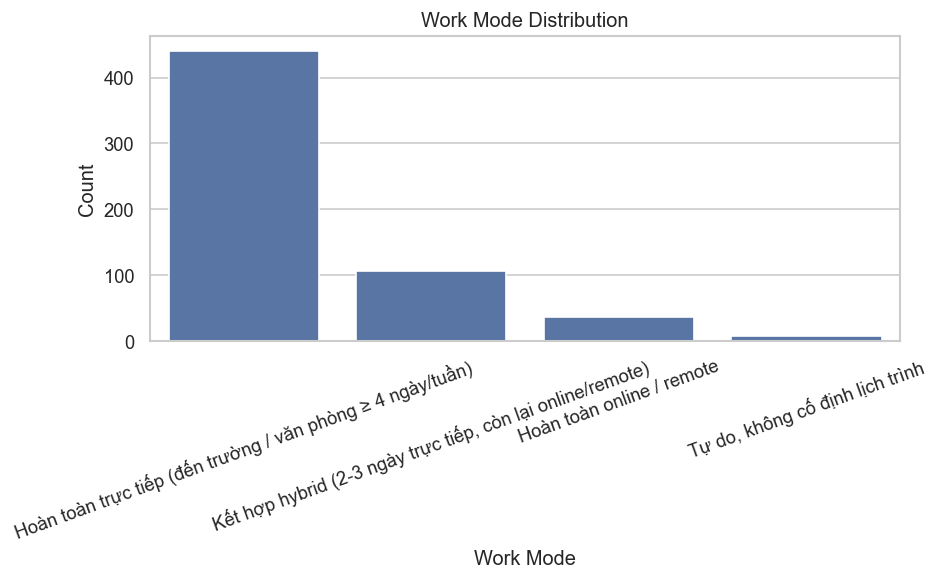

,count
work_mode,
Hoàn toàn trực tiếp (đến trường / văn phòng ≥ 4 ngày/tuần),441
"Kết hợp hybrid (2-3 ngày trực tiếp, còn lại online/remote)",106
Hoàn toàn online / remote,36
"Tự do, không cố định lịch trình",7


In [55]:
# Hiển thị phân bố biến Learning Context

plt.figure(figsize=(8,5))

sns.countplot(
    data=cleaned_dataset,
    x="work_mode",
    order=cleaned_dataset["work_mode"].value_counts().index
)

plt.title("Work Mode Distribution")
plt.xlabel("Work Mode")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

display(
    cleaned_dataset["work_mode"]
    .value_counts()
    .to_frame(name="count")
)

## 3.3 Digital Exposure

Phân tích phân bố của các biến phản ánh mức độ và đặc điểm tiếp xúc với công nghệ số của người tham gia khảo sát.


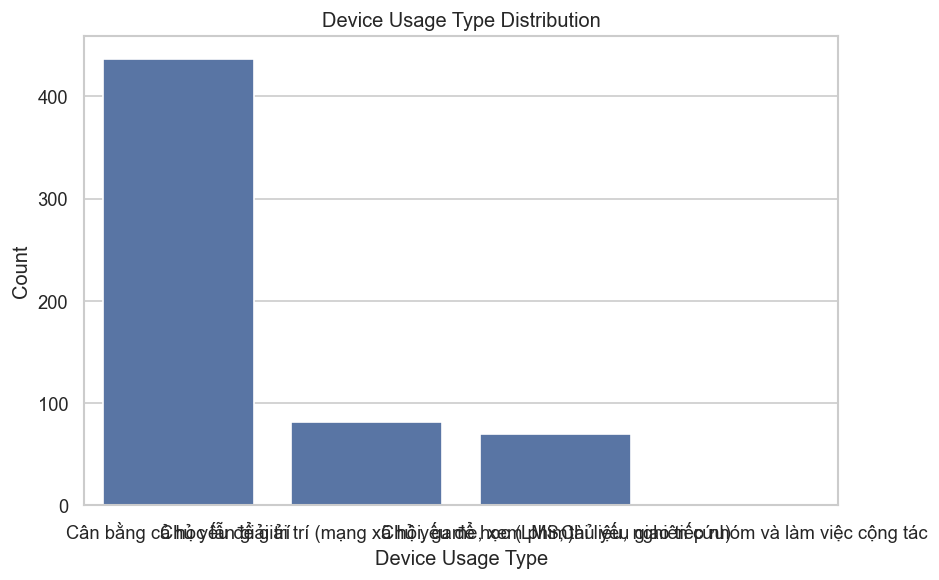

,count
device_usage_type,
Chủ yếu giao tiếp nhóm và làm việc cộng tác,1
"Chủ yếu để giải trí (mạng xã hội, game, xem phim)",82
"Chủ yếu để học (LMS, tài liệu, nghiên cứu)",70
Cân bằng cả học lẫn giải trí,437


--------------------------------------------------------------------------------


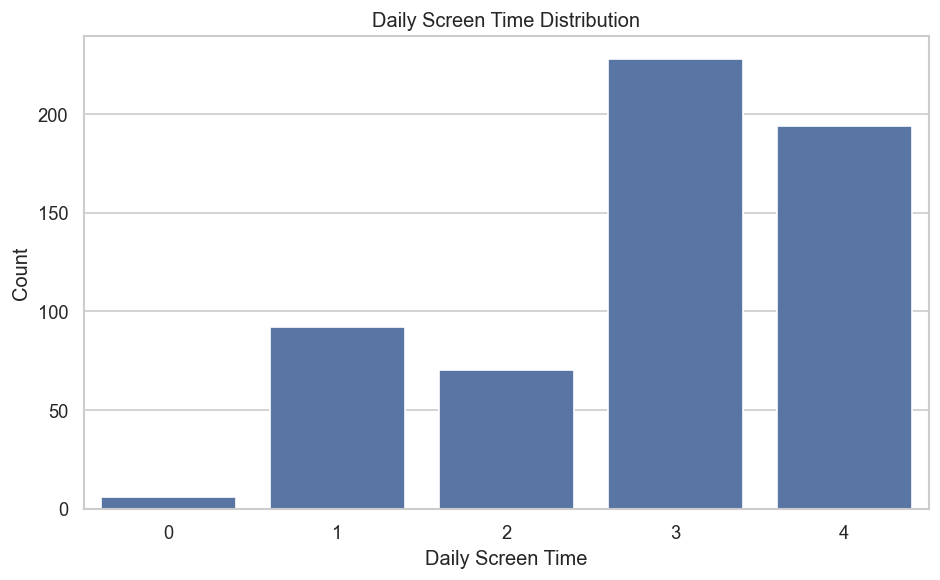

,count
daily_screen_time,
0,6
1,92
2,70
3,228
4,194


--------------------------------------------------------------------------------


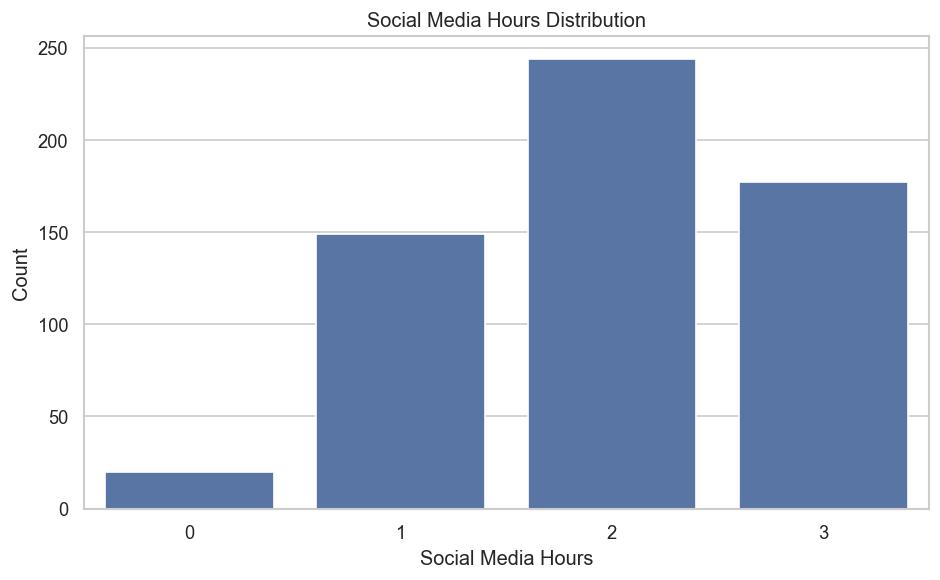

,count
social_media_hours,
0,20
1,149
2,244
3,177


--------------------------------------------------------------------------------


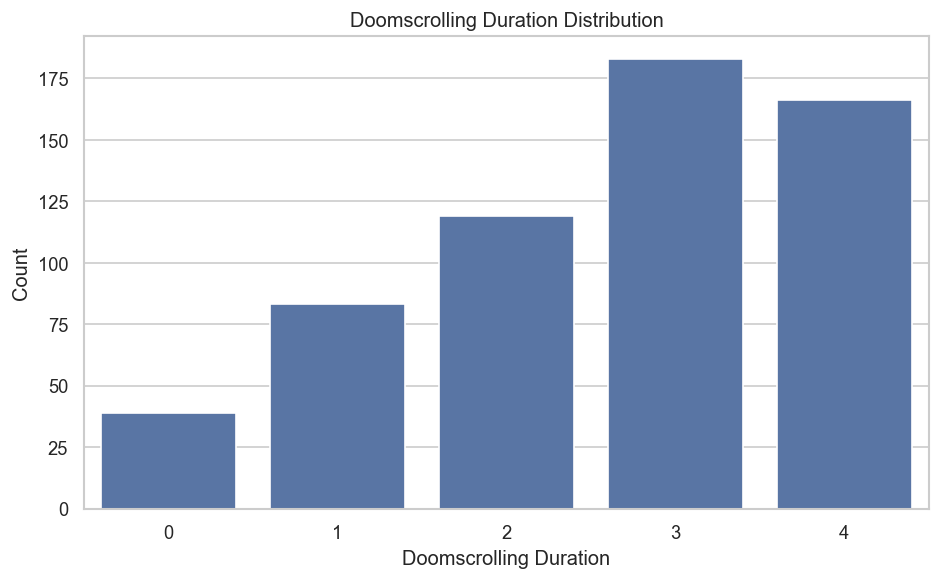

,count
doomscrolling_duration,
0,39
1,83
2,119
3,183
4,166


--------------------------------------------------------------------------------


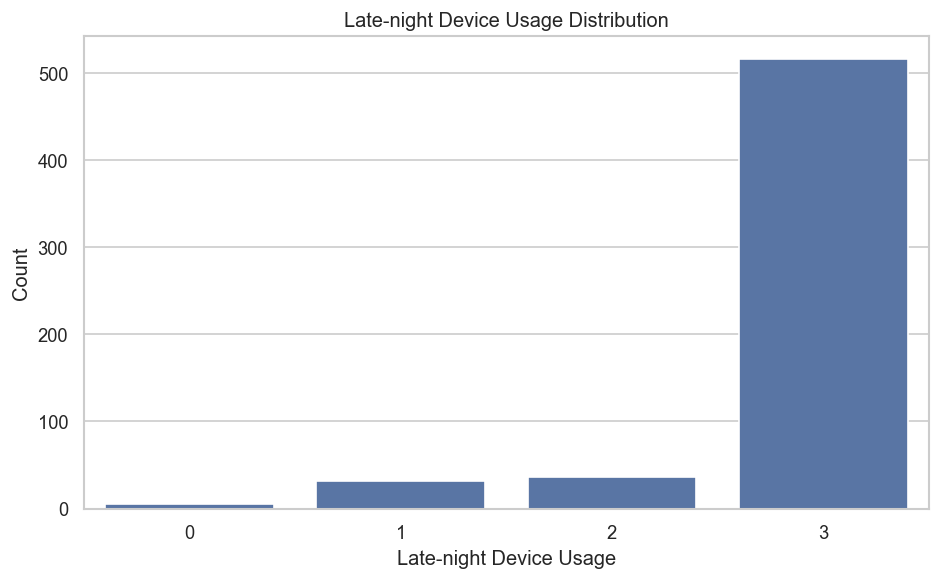

,count
late_night_device_usage,
0,5
1,32
2,36
3,517


--------------------------------------------------------------------------------


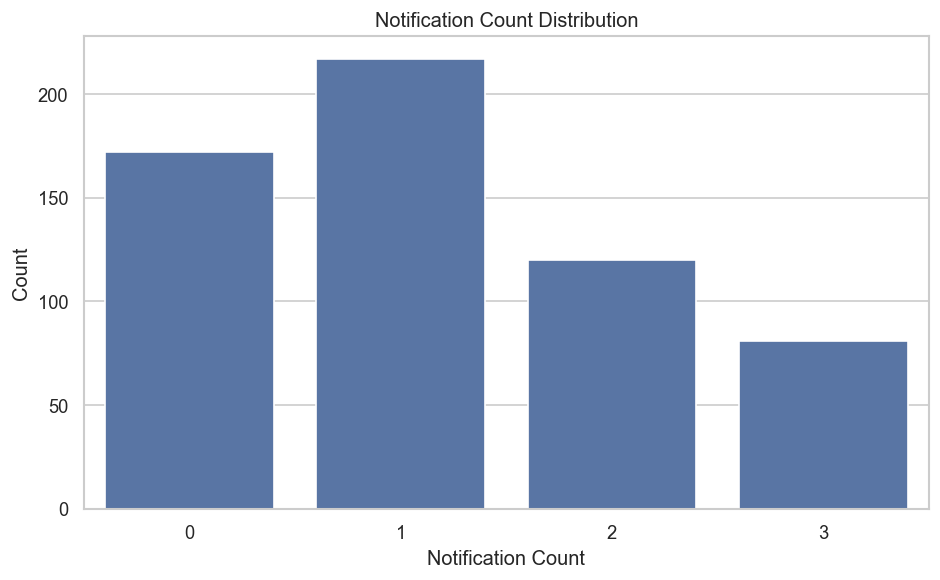

,count
notification_count,
0,172
1,217
2,120
3,81


--------------------------------------------------------------------------------


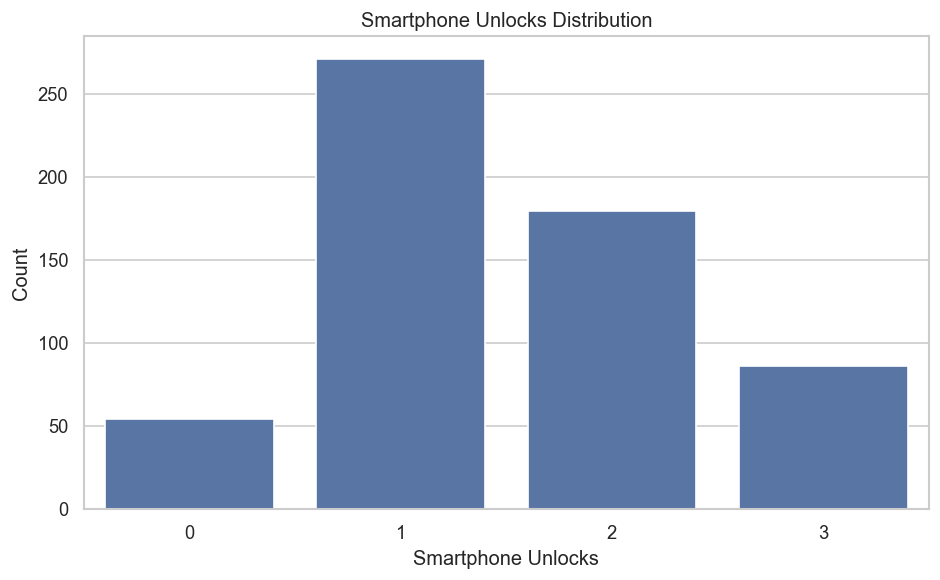

,count
smartphone_unlocks,
0,54
1,271
2,179
3,86


--------------------------------------------------------------------------------


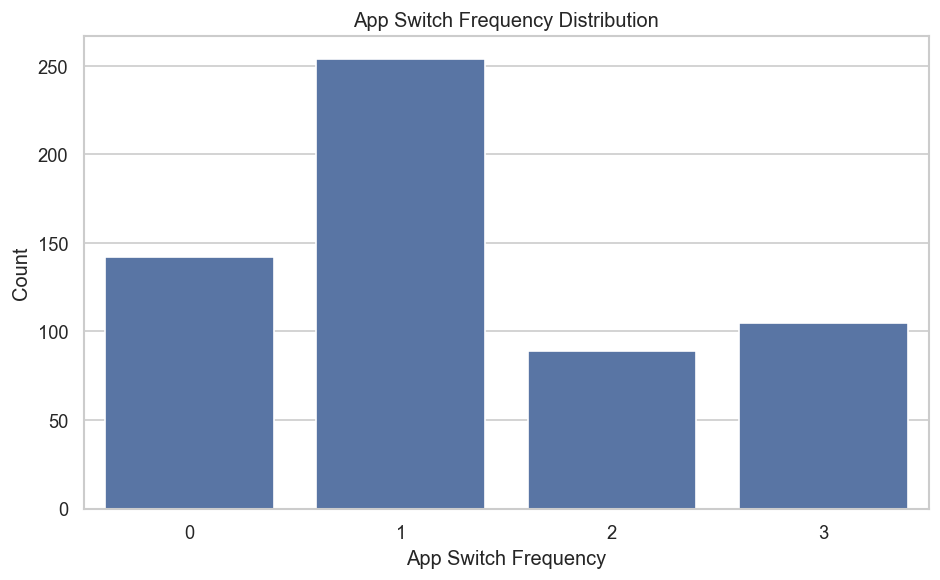

,count
app_switch_frequency,
0,142
1,254
2,89
3,105


--------------------------------------------------------------------------------


In [56]:
# Hiển thị phân bố các biến thuộc nhóm Digital Exposure

for column in digital_exposure_features:

    plt.figure(figsize=(8, 5))

    if cleaned_dataset[column].dtype == "object":

        order = cleaned_dataset[column].value_counts().index

    else:

        order = sorted(cleaned_dataset[column].dropna().unique())

    sns.countplot(
        data=cleaned_dataset,
        x=column,
        order=order
    )

    plt.title(f"{feature_labels[column]} Distribution")
    plt.xlabel(feature_labels[column])
    plt.ylabel("Count")

    plt.tight_layout()

    plt.show()

    distribution_summary = (
        cleaned_dataset[column]
        .value_counts()
        .sort_index()
        .to_frame(name="count")
    )

    display(distribution_summary)

    print("-" * 80)

## 3.4 Cognitive Performance

Phân tích phân bố của các biến phản ánh hiệu suất nhận thức và khả năng học tập của người tham gia khảo sát.

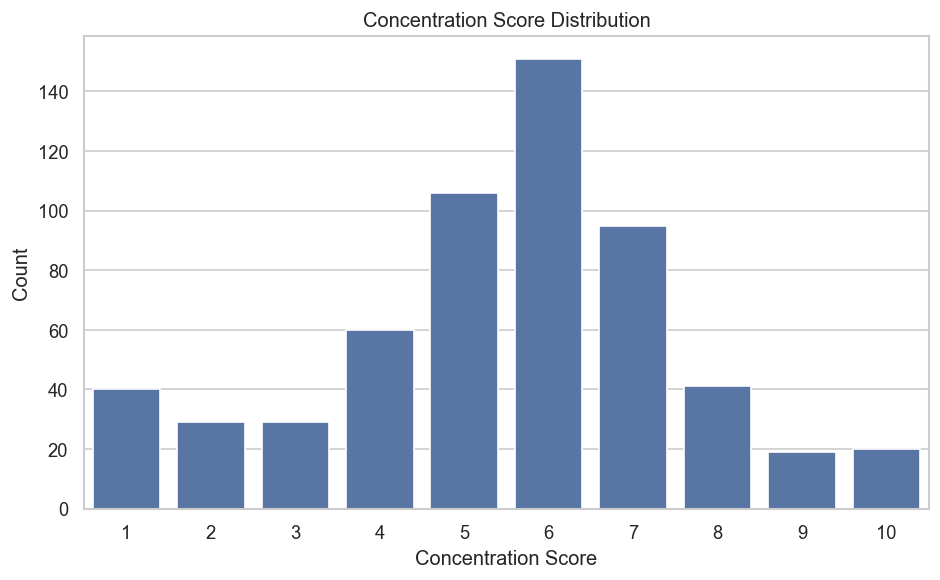

,count
concentration_score,
1,40
2,29
3,29
4,60
5,106
6,151
7,95
8,41
9,19


--------------------------------------------------------------------------------


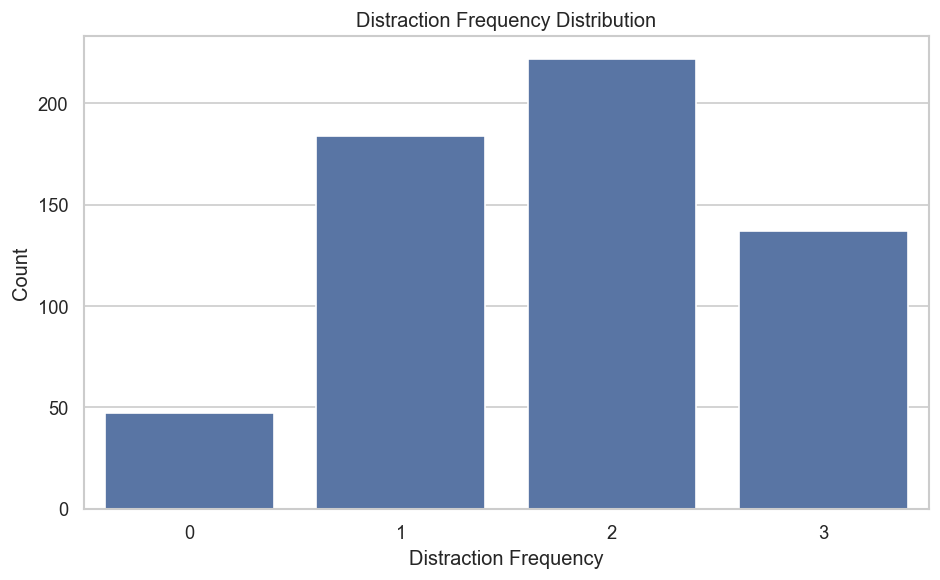

,count
distraction_frequency,
0,47
1,184
2,222
3,137


--------------------------------------------------------------------------------


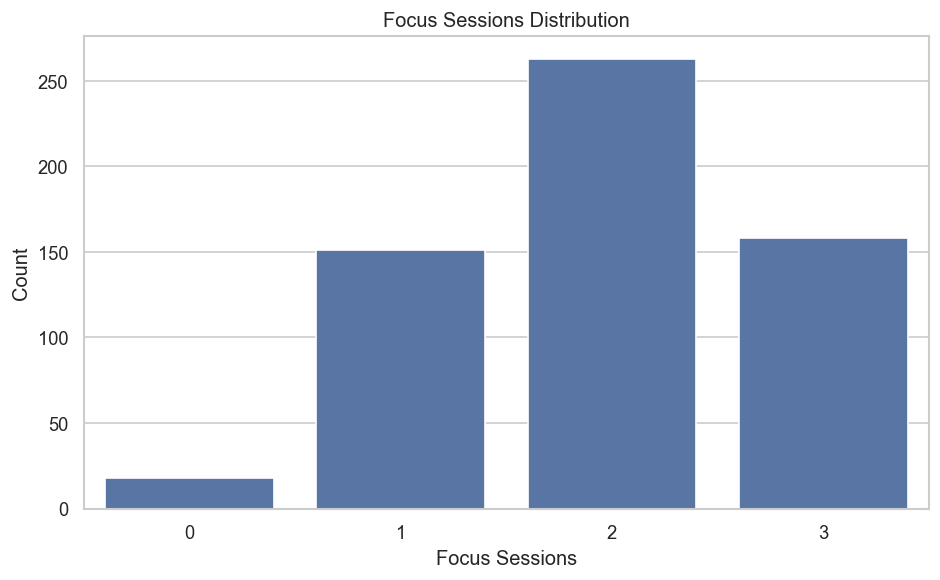

,count
focus_sessions,
0,18
1,151
2,263
3,158


--------------------------------------------------------------------------------


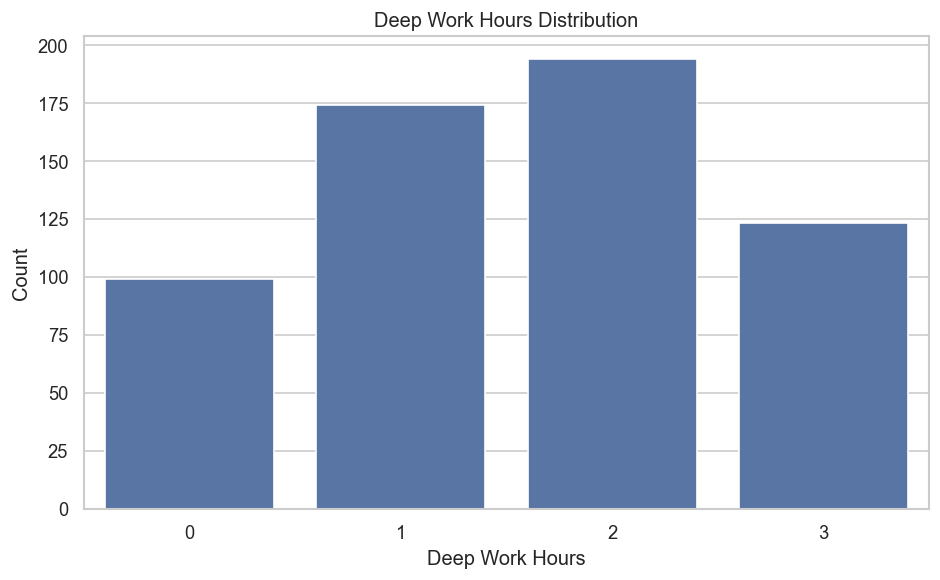

,count
deep_work_hours,
0,99
1,174
2,194
3,123


--------------------------------------------------------------------------------


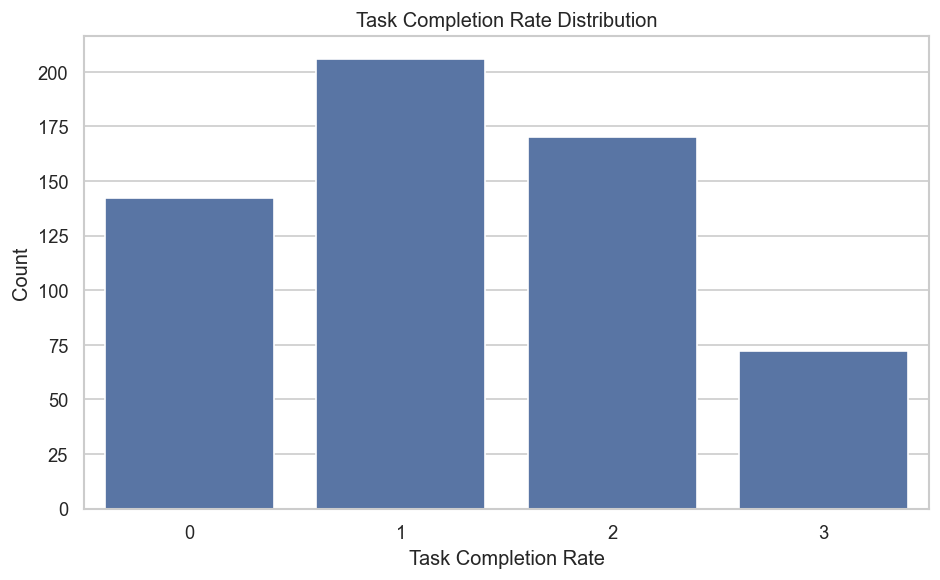

,count
task_completion_rate,
0,142
1,206
2,170
3,72


--------------------------------------------------------------------------------


In [57]:
# Hiển thị phân bố các biến thuộc nhóm Cognitive Performance

for column in cognitive_performance_features:

    plt.figure(figsize=(8, 5))

    if cleaned_dataset[column].dtype == "object":

        order = cleaned_dataset[column].value_counts().index

    else:

        order = sorted(cleaned_dataset[column].dropna().unique())

    sns.countplot(
        data=cleaned_dataset,
        x=column,
        order=order
    )

    label = feature_labels.get(column, column)

    plt.title(f"{label} Distribution")
    plt.xlabel(label)
    plt.ylabel("Count")

    plt.tight_layout()

    plt.show()

    distribution_summary = (
        cleaned_dataset[column]
        .value_counts()
        .sort_index()
        .to_frame(name="count")
    )

    display(distribution_summary)

    print("-" * 80)

## 3.5 Sleep & Recovery

Phân tích phân bố của các biến phản ánh thời lượng và chất lượng giấc ngủ của người tham gia khảo sát.


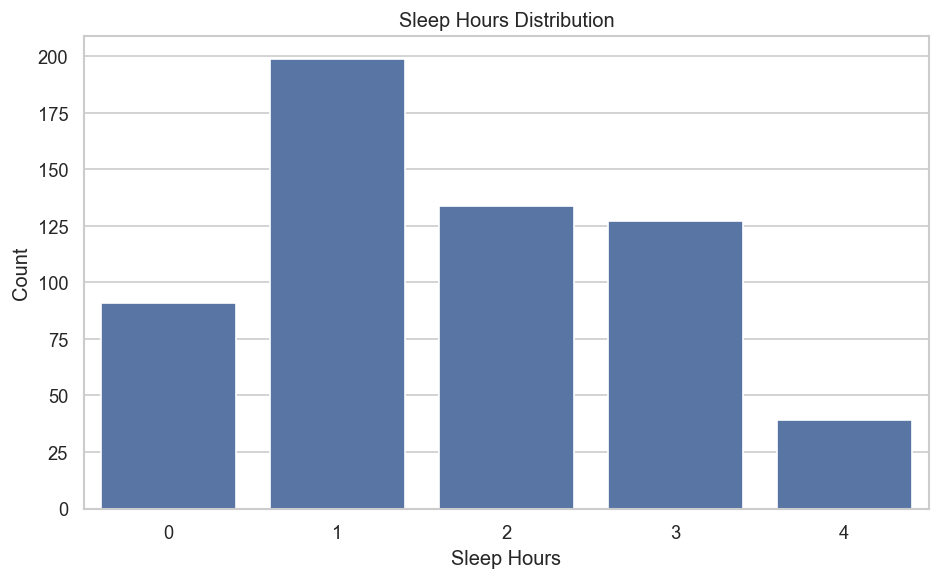

,count
sleep_hours,
0,91
1,199
2,134
3,127
4,39


--------------------------------------------------------------------------------


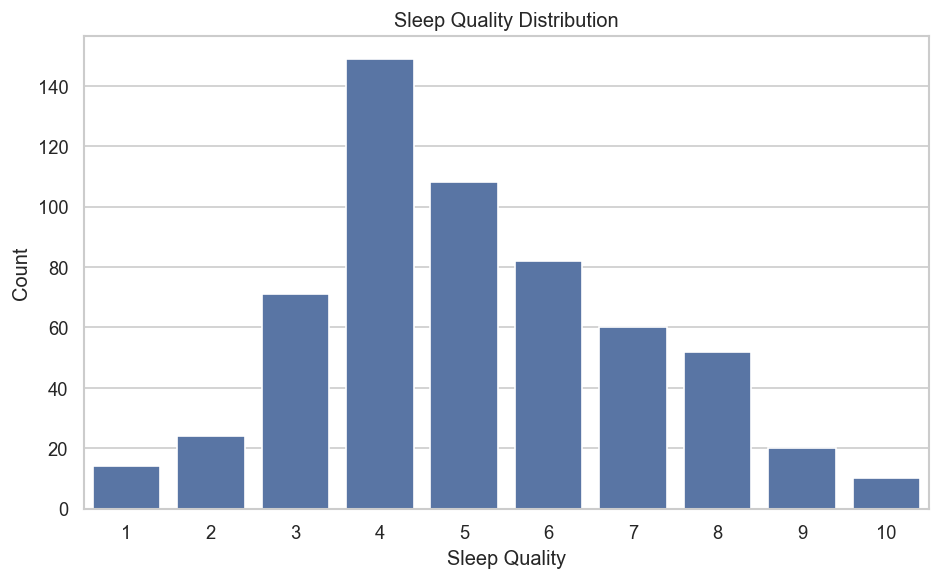

,count
sleep_quality,
1,14
2,24
3,71
4,149
5,108
6,82
7,60
8,52
9,20


--------------------------------------------------------------------------------


In [58]:
# Hiển thị phân bố các biến thuộc nhóm Sleep & Recovery

for column in sleep_recovery_features:

    plt.figure(figsize=(8, 5))

    if cleaned_dataset[column].dtype == "object":

        order = cleaned_dataset[column].value_counts().index

    else:

        order = sorted(cleaned_dataset[column].dropna().unique())

    sns.countplot(
        data=cleaned_dataset,
        x=column,
        order=order
    )

    label = feature_labels.get(column, column)

    plt.title(f"{label} Distribution")
    plt.xlabel(label)
    plt.ylabel("Count")

    plt.tight_layout()

    plt.show()

    distribution_summary = (
        cleaned_dataset[column]
        .value_counts()
        .sort_index()
        .to_frame(name="count")
    )

    display(distribution_summary)

    print("-" * 80)

# 4. Correlation Analysis

Phân tích mối tương quan giữa các biến định lượng trong bộ dữ liệu nhằm nhận diện xu hướng đồng biến hoặc nghịch biến giữa các đặc trưng nghiên cứu.

Kết quả phân tích chỉ mang tính khám phá dữ liệu và không được sử dụng để đưa ra kết luận về quan hệ nhân quả.


## 4.1 Correlation Matrix

Tính toán hệ số tương quan Pearson giữa các biến định lượng trong bộ dữ liệu.

In [59]:
# Tính toán ma trận tương quan

correlation_matrix = (
    cleaned_dataset[numeric_columns]
    .corr(method="pearson")
    .round(2)
)

correlation_matrix

,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,sleep_hours,sleep_quality,motivation_level,emotional_exhaustion,stress_level,mental_fatigue
daily_screen_time,1.00,0.08,0.12,0.16,-0.09,-0.03,-0.05,-0.01,0.05,0.04,0.03,-0.03,-0.05,-0.11,-0.07,0.09,0.11,0.08
social_media_hours,0.08,1.00,0.12,0.18,-0.06,-0.05,-0.01,0.00,-0.04,0.01,-0.02,-0.09,0.03,0.00,-0.08,0.08,0.02,0.09
doomscrolling_duration,0.12,0.12,1.00,0.12,-0.09,-0.02,-0.14,0.07,0.02,-0.01,0.00,-0.01,-0.07,-0.06,-0.05,0.12,0.18,0.09
late_night_device_usage,0.16,0.18,0.12,1.00,-0.07,-0.05,-0.10,0.06,0.12,0.10,0.08,-0.08,-0.09,-0.03,-0.01,0.25,0.18,0.19
notification_count,-0.09,-0.06,-0.09,-0.07,1.00,0.09,0.11,-0.10,-0.02,0.03,-0.10,0.02,0.03,0.02,0.04,-0.07,-0.11,-0.07
smartphone_unlocks,-0.03,-0.05,-0.02,-0.05,0.09,1.00,0.10,-0.06,-0.11,0.01,-0.00,-0.01,0.05,0.01,0.01,-0.04,-0.04,-0.14
app_switch_frequency,-0.05,-0.01,-0.14,-0.10,0.11,0.10,1.00,-0.02,0.00,-0.07,-0.03,0.03,-0.06,0.07,0.09,-0.09,-0.09,-0.07
concentration_score,-0.01,0.00,0.07,0.06,-0.10,-0.06,-0.02,1.00,-0.07,0.02,0.11,-0.02,-0.02,0.05,0.09,-0.01,0.01,0.01
distraction_frequency,0.05,-0.04,0.02,0.12,-0.02,-0.11,0.00,-0.07,1.00,0.02,0.05,-0.11,-0.06,-0.03,-0.02,0.09,0.14,0.03
focus_sessions,0.04,0.01,-0.01,0.10,0.03,0.01,-0.07,0.02,0.02,1.00,-0.06,-0.11,-0.00,-0.14,-0.12,0.13,-0.05,0.01


## 4.2 Correlation Heatmap

Trực quan hóa ma trận tương quan nhằm hỗ trợ quan sát nhanh các cặp biến có mức tương quan đáng chú ý.

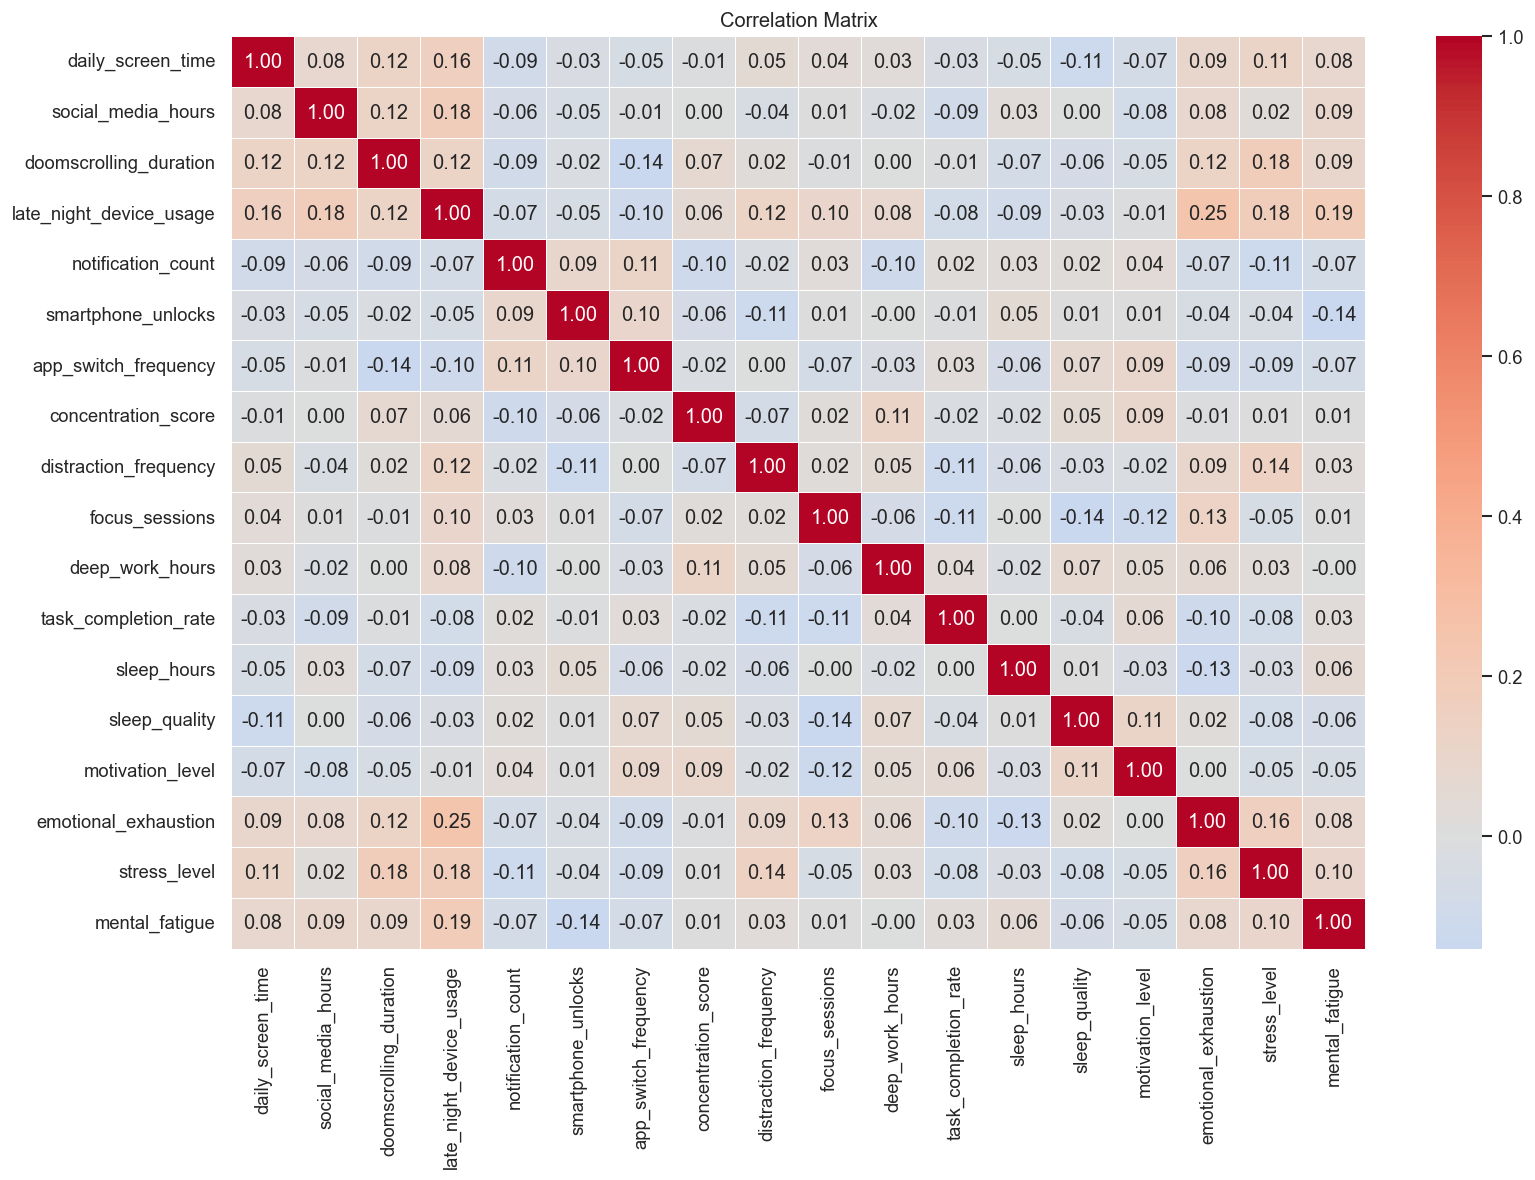

In [60]:
# Trực quan hóa ma trận tương quan

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

## 4.3 Top Correlated Feature Pairs

Xác định các cặp biến có hệ số tương quan lớn nhất trong bộ dữ liệu nhằm hỗ trợ quá trình phân tích khám phá.

In [61]:
# Trích xuất các cặp biến có tương quan cao nhất

correlation_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "feature_1",
    "feature_2",
    "correlation"
]

correlation_pairs["absolute_correlation"] = (
    correlation_pairs["correlation"].abs()
)

top_correlation_pairs = (
    correlation_pairs
    .sort_values(
        by="absolute_correlation",
        ascending=False
    )
    .head(10)
)

top_correlation_pairs

,feature_1,feature_2,correlation,absolute_correlation
59,late_night_device_usage,emotional_exhaustion,0.25,0.25
61,late_night_device_usage,mental_fatigue,0.19,0.19
46,doomscrolling_duration,stress_level,0.18,0.18
60,late_night_device_usage,stress_level,0.18,0.18
18,social_media_hours,late_night_device_usage,0.18,0.18
2,daily_screen_time,late_night_device_usage,0.16,0.16
150,emotional_exhaustion,stress_level,0.16,0.16
86,smartphone_unlocks,mental_fatigue,-0.14,0.14
115,distraction_frequency,stress_level,0.14,0.14
36,doomscrolling_duration,app_switch_frequency,-0.14,0.14


# 5. Relationship Analysis

Khám phá mối quan hệ giữa các nhóm biến nghiên cứu trong Digital Burnout Framework nhằm cung cấp cái nhìn trực quan về sự biến thiên giữa các đặc trưng trước khi thực hiện Feature Validation.

## 5.1 Digital Exposure and Cognitive Performance

Khảo sát mối quan hệ giữa mức độ sử dụng thiết bị số và khả năng tập trung của người tham gia khảo sát.

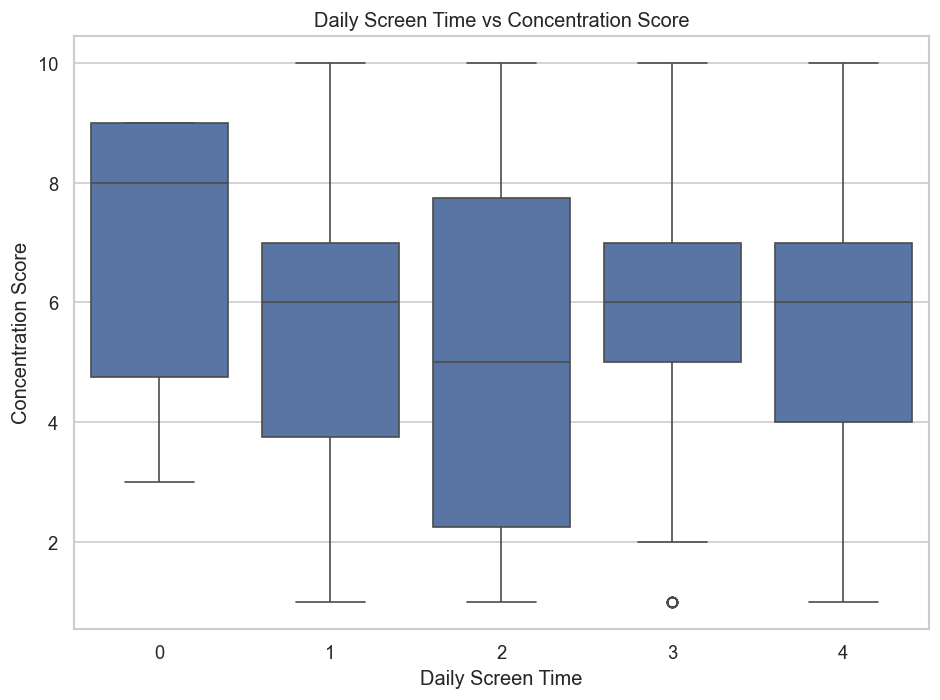

In [62]:
# Quan hệ giữa thời gian sử dụng thiết bị và khả năng tập trung

plt.figure(figsize=(8,6))

sns.boxplot(
    data=cleaned_dataset,
    x="daily_screen_time",
    y="concentration_score"
)

plt.title("Daily Screen Time vs Concentration Score")
plt.xlabel("Daily Screen Time")
plt.ylabel("Concentration Score")

plt.tight_layout()

plt.show()

## 5.2 Cognitive Performance and Sleep & Recovery

Khảo sát mối quan hệ giữa hiệu suất nhận thức và chất lượng phục hồi thông qua các chỉ số về thời gian tập trung sâu và chất lượng giấc ngủ.

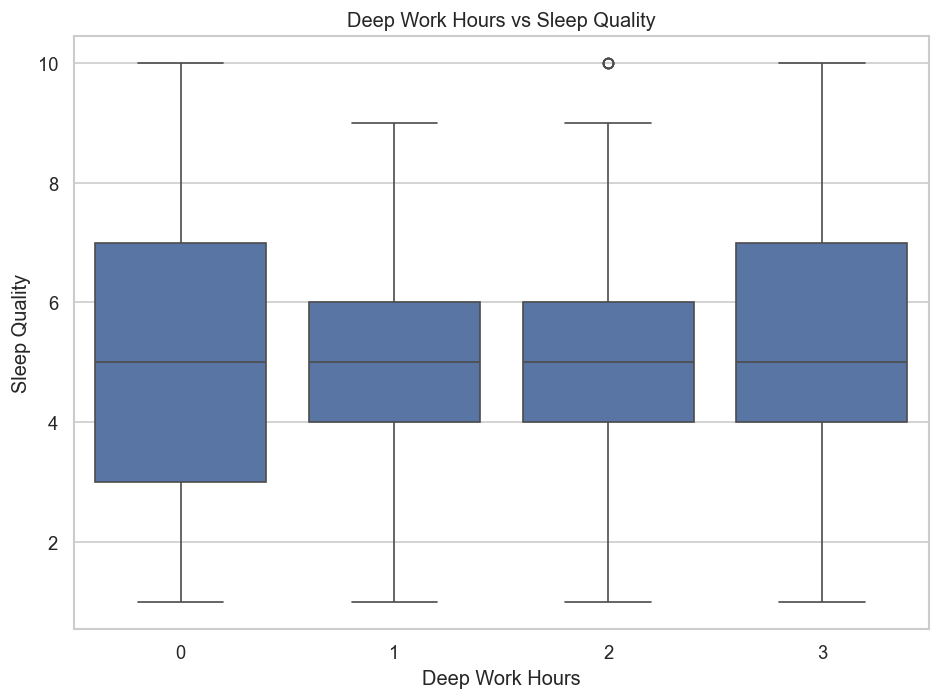

In [63]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=cleaned_dataset,
    x="deep_work_hours",
    y="sleep_quality"
)

plt.title("Deep Work Hours vs Sleep Quality")
plt.xlabel("Deep Work Hours")
plt.ylabel("Sleep Quality")

plt.tight_layout()

plt.show()

## 5.3 Sleep & Recovery and Burnout Symptoms

Khảo sát mối quan hệ giữa thời lượng giấc ngủ và các triệu chứng Digital Burnout nhằm quan sát sự biến thiên của mức độ mệt mỏi tinh thần theo các nhóm thời gian ngủ.

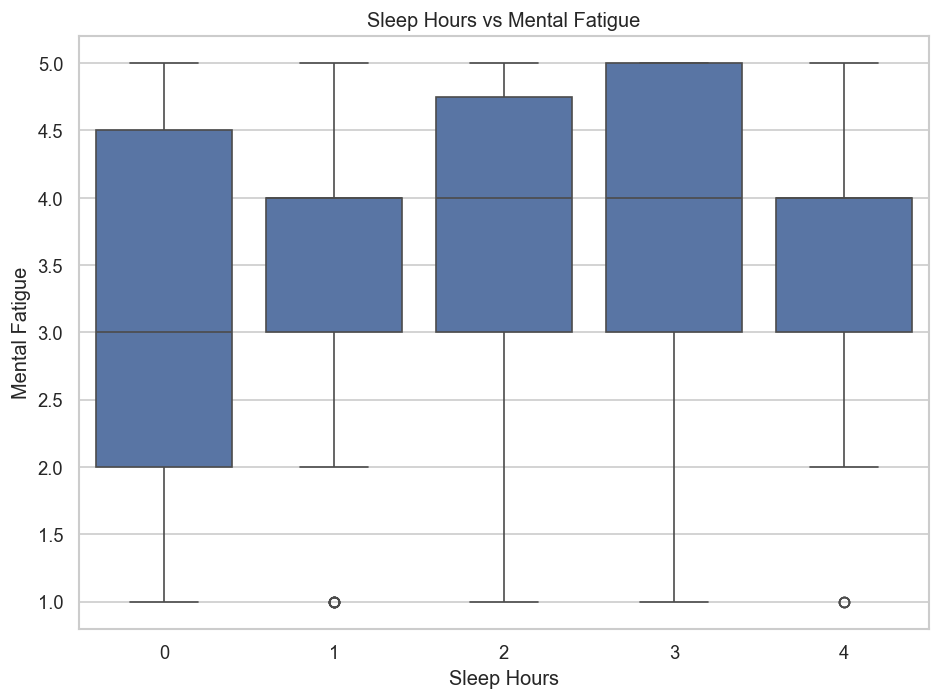

In [64]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=cleaned_dataset,
    x="sleep_hours",
    y="mental_fatigue"
)

plt.title("Sleep Hours vs Mental Fatigue")
plt.xlabel("Sleep Hours")
plt.ylabel("Mental Fatigue")

plt.tight_layout()

plt.show()